In [ ]:
import pandas as pd
import gdown
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import matplotlib.ticker as mtick
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
import plotly.express as px
import matplotlib.dates as mdates
import re
from sklearn.feature_extraction.text import CountVectorizer
from textblob import TextBlob

import warnings
warnings.filterwarnings('ignore')

##Scraping Data

In [ ]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.2 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import reviews, Sort

result, continuation_token = reviews(
    'com.icon.pln123',  # Ganti dengan package name aplikasi
    lang='id',          # Bahasa ulasan
    country='id',       # Negara pengguna
    sort=Sort.NEWEST,   # Sortir ulasan
    count=500           # Jumlah ulasan yang diambil
)

data = [{
    'userName': r['userName'],
    'score': r['score'],
    'datetime': r['at'].strftime('%Y-%m-%d %H:%M:%S'),
    'reviewText': r['content']
} for r in result]

# Buat DataFrame
df = pd.DataFrame(data)

df.head()

,userName,score,datetime,reviewText
0,Bambang Triaji,5,2025-06-27 22:55:06,cepat dan respon cepat
1,Jas Min,5,2025-06-27 22:47:25,Lebh d tnggkatkn pelayanan nya
2,Adi Susanto,5,2025-06-27 22:47:16,PLN mantap
3,Rifki Riki,5,2025-06-27 22:30:50,Mantappp
4,Muhammad Faujan,5,2025-06-27 22:30:01,mantap pokoknya


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   userName    500 non-null    object
 1   score       500 non-null    int64 
 2   datetime    500 non-null    object
 3   reviewText  500 non-null    object
dtypes: int64(1), object(3)
memory usage: 15.8+ KB


## Data Preprocessing

####**Data Transformation**



In [ ]:
# ganti tipe data
df['datetime'] = pd.to_datetime(df['datetime'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   userName    500 non-null    object        
 1   score       500 non-null    int64         
 2   datetime    500 non-null    datetime64[ns]
 3   reviewText  500 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 15.8+ KB


####**Duplicate checking**

In [ ]:
# Cek duplikasi by nama dan email
duplicate_rows = df[df.duplicated(subset=['userName', 'reviewText'], keep=False)]
print(f"jumlah duplikasi : {len(duplicate_rows)}")
df.drop_duplicates(subset=['userName', 'reviewText'],keep='first', inplace=True)

jumlah duplikasi : 0


####**Null Values checking**

In [ ]:
# Cek null values
df.isnull().sum()

,0
userName,0
score,0
datetime,0
reviewText,0


In [ ]:
df.shape

(500, 4)

In [ ]:
df.head(5)

,userName,score,datetime,reviewText
0,Bambang Triaji,5,2025-06-27 22:55:06,cepat dan respon cepat
1,Jas Min,5,2025-06-27 22:47:25,Lebh d tnggkatkn pelayanan nya
2,Adi Susanto,5,2025-06-27 22:47:16,PLN mantap
3,Rifki Riki,5,2025-06-27 22:30:50,Mantappp
4,Muhammad Faujan,5,2025-06-27 22:30:01,mantap pokoknya


# Wordcloud Preprocessing

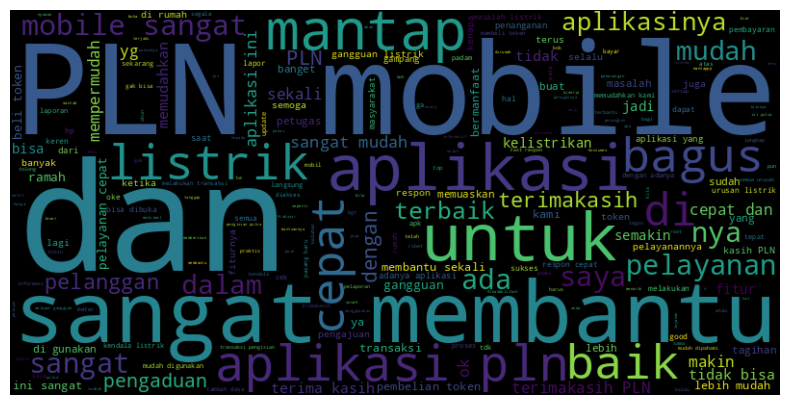

In [ ]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

# Mengisi nilai NaN dengan string kosong ('')
df['reviewText'] = df['reviewText'].fillna(" ")

# Menggabungkan teks dari kolom 'Review text'
text=' '.join(df['reviewText'].astype(str).tolist())

stopwords = set(STOPWORDS)

wc = WordCloud(stopwords=stopwords, background_color="black", max_words=500, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt. axis("off")
plt. show()

### Word Frequent Checking

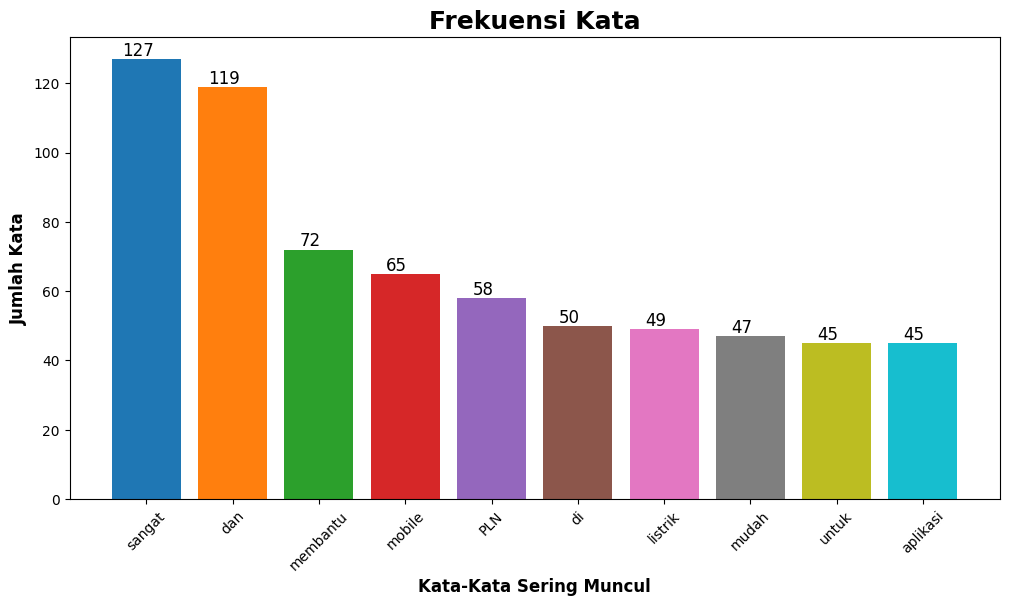

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

text = "".join(df["reviewText"])

tokens = text.split()
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)

word, count = zip(*top_words)

# palet warna
colors = plt.cm.tab10(range(len(word)))

plt.figure(figsize=(12, 6))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')

plt.show()

### Cleaning

In [ ]:
import re
import string
import nltk

# Fungsi untuk menghapus emoji
! pip install emoji
import emoji

def remove_emoji(text):
    if text is not None and isinstance(text, str):
        return emoji.replace_emoji(text, replace='')
    return text

# Fungsi untuk menghapus simbol
def remove_symbols(text):
    if text is not None and isinstance(text, str):
        text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

# Fungsi untuk menghapus angka
def remove_numbers(text):
    if text is not None and isinstance(text, str):
        text = re.sub(r'\d+', '', text)
    return text

# Fungsi untuk menambahkan spasi setelah koma
def add_space_after_comma(text):
    if text is not None and isinstance(text, str):
        return re.sub(r',(?=\S)', ', ', text)
    return text

df['Cleaning'] = df['reviewText'].apply(lambda x: add_space_after_comma(x))
df['Cleaning'] = df['Cleaning'].apply(lambda x: remove_emoji(x))
df['Cleaning'] = df['Cleaning'].apply(lambda x: remove_symbols(x))
df['Cleaning'] = df['Cleaning'].apply(lambda x: remove_numbers(x))

df.head(10)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 33.7 MB/s eta 0:00:00


,userName,score,datetime,reviewText,Cleaning
0,Bambang Triaji,5,2025-06-27 22:55:06,cepat dan respon cepat,cepat dan respon cepat
1,Jas Min,5,2025-06-27 22:47:25,Lebh d tnggkatkn pelayanan nya,Lebh d tnggkatkn pelayanan nya
2,Adi Susanto,5,2025-06-27 22:47:16,PLN mantap,PLN mantap
3,Rifki Riki,5,2025-06-27 22:30:50,Mantappp,Mantappp
4,Muhammad Faujan,5,2025-06-27 22:30:01,mantap pokoknya,mantap pokoknya
5,Vira Indriani,5,2025-06-27 20:44:13,dapat rekomendasi dari temen apk ini bisa mere...,dapat rekomendasi dari temen apk ini bisa mere...
6,Angga Febriansyah,5,2025-06-27 20:07:42,"aplikasinya sangat recommended, semuanya jadi ...",aplikasinya sangat recommended semuanya jadi m...
7,Samenda Reza,5,2025-06-27 19:50:20,aplikasi yang sangat baik👍👍,aplikasi yang sangat baik
8,Salamudin,5,2025-06-27 19:40:21,bagud,bagud
9,galih himawan,1,2025-06-27 19:31:26,kok GK bisa dibuka,kok GK bisa dibuka


### Case Folding

In [ ]:
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
        return text

df['case_folding'] = df['Cleaning'].apply(case_folding)
df

,userName,score,datetime,reviewText,Cleaning,case_folding
0,Bambang Triaji,5,2025-06-27 22:55:06,cepat dan respon cepat,cepat dan respon cepat,cepat dan respon cepat
1,Jas Min,5,2025-06-27 22:47:25,Lebh d tnggkatkn pelayanan nya,Lebh d tnggkatkn pelayanan nya,lebh d tnggkatkn pelayanan nya
2,Adi Susanto,5,2025-06-27 22:47:16,PLN mantap,PLN mantap,pln mantap
3,Rifki Riki,5,2025-06-27 22:30:50,Mantappp,Mantappp,mantappp
4,Muhammad Faujan,5,2025-06-27 22:30:01,mantap pokoknya,mantap pokoknya,mantap pokoknya
...,...,...,...,...,...,...
495,Mahyud din,5,2025-06-27 00:15:21,adanya PLN mobile sangat mudah untuk transaksi...,adanya PLN mobile sangat mudah untuk transaksi...,adanya pln mobile sangat mudah untuk transaksi...
496,benno jaenudin,5,2025-06-27 00:15:15,aplikasi ini membantu juga mempermudah semua u...,aplikasi ini membantu juga mempermudah semua u...,aplikasi ini membantu juga mempermudah semua u...
497,Feri,5,2025-06-27 00:12:50,aplikasi pln mantap dan baik,aplikasi pln mantap dan baik,aplikasi pln mantap dan baik
498,Feyby Bantung,5,2025-06-27 00:11:45,sangat membantu dan mempermudah pelanggan dala...,sangat membantu dan mempermudah pelanggan dala...,sangat membantu dan mempermudah pelanggan dala...


### World Normalization

In [ ]:
import pandas as pd

# fungsi penggantian kata tidak baku
def replace_taboo_words (text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()
        replaced_words = []
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]
                if isinstance(baku_word, str) and all(char.isalpha() for char in baku_word):
                    replaced_words.append(baku_word)
                    kalimat_baku.append(baku_word)
                    kata_diganti.append(word)
                    kata_tidak_baku_hash.append(hash (word))
                # else:
                #   replaced_words.append('<karakter eksplisit"।
                #   kalimat_baku.append(word)
            else:
                replaced_words.append(word)
        # Corrected indentation here
        replaced_text = ' '.join(replaced_words)
    else:
        replaced_text = ''
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []
    # Corrected indentation here
    return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash

In [ ]:
# Membaca kamus kata tidak baku
kamus_data = pd.read_excel("kamuskatabaku.xlsx")
kamus_tidak_baku = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))

In [ ]:
#Menerapkan Fungsi Penggantian Kata Tidak Baku
df['normalisasi'], df['Kata_Baku'], df['Kata_Tidak_Baku'], df['Kata_Tidak_Baku_Hash'] = zip(
    *df['case_folding'].apply(lambda x: replace_taboo_words(x, kamus_tidak_baku))
)
df = pd.DataFrame(df[['datetime', 'userName', 'score', 'reviewText', 'Cleaning', 'case_folding', 'normalisasi']])


In [ ]:
df

,datetime,userName,score,reviewText,Cleaning,case_folding,normalisasi,tokenize
0,2025-06-27 22:55:06,Bambang Triaji,5,cepat dan respon cepat,cepat dan respon cepat,cepat dan respon cepat,cepat dan respon cepat,"[cepat, dan, respon, cepat]"
1,2025-06-27 22:47:25,Jas Min,5,Lebh d tnggkatkn pelayanan nya,Lebh d tnggkatkn pelayanan nya,lebh d tnggkatkn pelayanan nya,lebih di tnggkatkn pelayanan ya,"[lebih, di, tnggkatkn, pelayanan, ya]"
2,2025-06-27 22:47:16,Adi Susanto,5,PLN mantap,PLN mantap,pln mantap,pln mantap,"[pln, mantap]"
3,2025-06-27 22:30:50,Rifki Riki,5,Mantappp,Mantappp,mantappp,mantap,[mantap]
4,2025-06-27 22:30:01,Muhammad Faujan,5,mantap pokoknya,mantap pokoknya,mantap pokoknya,mantap pokoknya,"[mantap, pokoknya]"
...,...,...,...,...,...,...,...,...
495,2025-06-27 00:15:21,Mahyud din,5,adanya PLN mobile sangat mudah untuk transaksi...,adanya PLN mobile sangat mudah untuk transaksi...,adanya pln mobile sangat mudah untuk transaksi...,adanya pln mobile sangat mudah untuk transaksi...,"[adanya, pln, mobile, sangat, mudah, untuk, tr..."
496,2025-06-27 00:15:15,benno jaenudin,5,aplikasi ini membantu juga mempermudah semua u...,aplikasi ini membantu juga mempermudah semua u...,aplikasi ini membantu juga mempermudah semua u...,aplikasi ini membantu juga mempermudah semua u...,"[aplikasi, ini, membantu, juga, mempermudah, s..."
497,2025-06-27 00:12:50,Feri,5,aplikasi pln mantap dan baik,aplikasi pln mantap dan baik,aplikasi pln mantap dan baik,aplikasi pln mantap dan baik,"[aplikasi, pln, mantap, dan, baik]"
498,2025-06-27 00:11:45,Feyby Bantung,5,sangat membantu dan mempermudah pelanggan dala...,sangat membantu dan mempermudah pelanggan dala...,sangat membantu dan mempermudah pelanggan dala...,sangat membantu dan mempermudah pelanggan dala...,"[sangat, membantu, dan, mempermudah, pelanggan..."


# Text Preprocessing

## Tokenization

In [ ]:
def tokenize (text) :
  tokens = text.split()
  return tokens

df['tokenize'] = df['normalisasi'].apply(lambda x: tokenize(x))

df_cleaned = df[['datetime', 'userName', 'score', 'normalisasi', 'tokenize']].rename(columns={'normalisasi':'reviewText_cleaned'})
df_cleaned.head()


,datetime,userName,score,reviewText_cleaned,tokenize
0,2025-06-27 22:55:06,Bambang Triaji,5,cepat dan respon cepat,"[cepat, dan, respon, cepat]"
1,2025-06-27 22:47:25,Jas Min,5,lebih di tnggkatkn pelayanan ya,"[lebih, di, tnggkatkn, pelayanan, ya]"
2,2025-06-27 22:47:16,Adi Susanto,5,pln mantap,"[pln, mantap]"
3,2025-06-27 22:30:50,Rifki Riki,5,mantap,[mantap]
4,2025-06-27 22:30:01,Muhammad Faujan,5,mantap pokoknya,"[mantap, pokoknya]"


## Proses Stopword Removal

In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('indonesian'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def remove_stopwords(text) :
  return [word for word in text if word not in stop_words]

df_cleaned['stopword removal'] = df_cleaned['tokenize'].apply(lambda x: remove_stopwords(x))
df_cleaned

,datetime,userName,score,reviewText_cleaned,tokenize,stopword removal
0,2025-06-27 22:55:06,Bambang Triaji,5,cepat dan respon cepat,"[cepat, dan, respon, cepat]","[cepat, respon, cepat]"
1,2025-06-27 22:47:25,Jas Min,5,lebih di tnggkatkn pelayanan ya,"[lebih, di, tnggkatkn, pelayanan, ya]","[tnggkatkn, pelayanan, ya]"
2,2025-06-27 22:47:16,Adi Susanto,5,pln mantap,"[pln, mantap]","[pln, mantap]"
3,2025-06-27 22:30:50,Rifki Riki,5,mantap,[mantap],[mantap]
4,2025-06-27 22:30:01,Muhammad Faujan,5,mantap pokoknya,"[mantap, pokoknya]","[mantap, pokoknya]"
...,...,...,...,...,...,...
495,2025-06-27 00:15:21,Mahyud din,5,adanya pln mobile sangat mudah untuk transaksi...,"[adanya, pln, mobile, sangat, mudah, untuk, tr...","[pln, mobile, mudah, transaksi, pembayaran, ta..."
496,2025-06-27 00:15:15,benno jaenudin,5,aplikasi ini membantu juga mempermudah semua u...,"[aplikasi, ini, membantu, juga, mempermudah, s...","[aplikasi, membantu, mempermudah, urusan, keli..."
497,2025-06-27 00:12:50,Feri,5,aplikasi pln mantap dan baik,"[aplikasi, pln, mantap, dan, baik]","[aplikasi, pln, mantap]"
498,2025-06-27 00:11:45,Feyby Bantung,5,sangat membantu dan mempermudah pelanggan dala...,"[sangat, membantu, dan, mempermudah, pelanggan...","[membantu, mempermudah, pelanggan, aplikasi, p..."


## Proses Steaming Data

In [ ]:
!pip install Sastrawi

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 15.0 MB/s eta 0:00:00


In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text):
    return [stemmer.stem(word) for word in text]

df_cleaned['steming_data'] = df_cleaned['stopword removal'].apply(lambda x: ' '.join(stem_text(x))).replace('', np.nan)
df_cleaned.head(5)

,datetime,userName,score,reviewText_cleaned,tokenize,stopword removal,steming_data
0,2025-06-09 07:13:28,Engel Bertus,5,aplikasi sudah sangat bagustapi sering ada gan...,"[aplikasi, sudah, sangat, bagustapi, sering, a...","[aplikasi, bagustapi, gangguan, error, jaya, pln]",aplikasi bagustapi ganggu error jaya pln
1,2025-06-09 07:12:44,Inggit Fatmawati,5,aplikasi pln sangat membantu pembelian token s...,"[aplikasi, pln, sangat, membantu, pembelian, t...","[aplikasi, pln, membantu, pembelian, token, se...",aplikasi pln bantu beli token moga aplikasi pl...
2,2025-06-09 07:12:37,dodi tri lesmana,5,terimakasih pln mobile terbaikkkk,"[terimakasih, pln, mobile, terbaikkkk]","[terimakasih, pln, mobile, terbaikkkk]",terimakasih pln mobile terbaikkkk
3,2025-06-09 07:10:23,Sandi Agasti,5,pelayanan oke cepat,"[pelayanan, oke, cepat]","[pelayanan, oke, cepat]",layan oke cepat
4,2025-06-09 07:09:11,Toni Saekoko,5,pln mobile oke,"[pln, mobile, oke]","[pln, mobile, oke]",pln mobile oke


In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   datetime            500 non-null    datetime64[ns]
 1   userName            500 non-null    object        
 2   score               500 non-null    int64         
 3   reviewText_cleaned  500 non-null    object        
 4   tokenize            500 non-null    object        
 5   stopword removal    500 non-null    object        
 6   steming_data        495 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 27.5+ KB


In [ ]:
data = df_cleaned.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 495 entries, 0 to 499
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   datetime            495 non-null    datetime64[ns]
 1   userName            495 non-null    object        
 2   score               495 non-null    int64         
 3   reviewText_cleaned  495 non-null    object        
 4   tokenize            495 non-null    object        
 5   stopword removal    495 non-null    object        
 6   steming_data        495 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 30.9+ KB


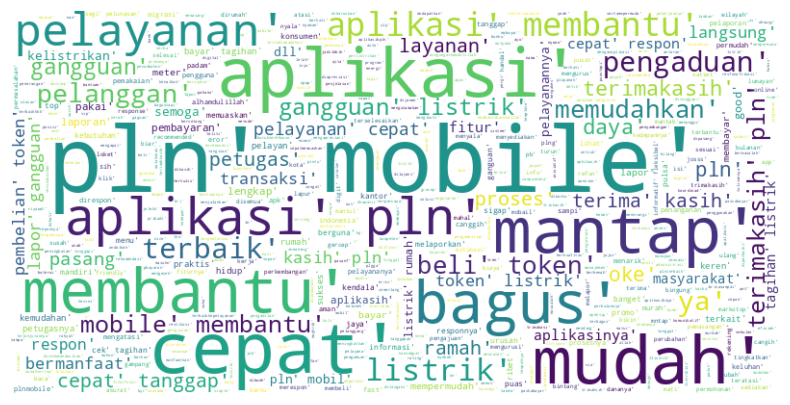

In [ ]:
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

# Menggabungkan teks dari kolom 'steming_data'
text = ' '.join(df_cleaned['stopword removal'].astype(str).tolist())

stopwords = set(STOPWORDS)

wc = WordCloud(stopwords=stopwords, background_color="white", max_words=500, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

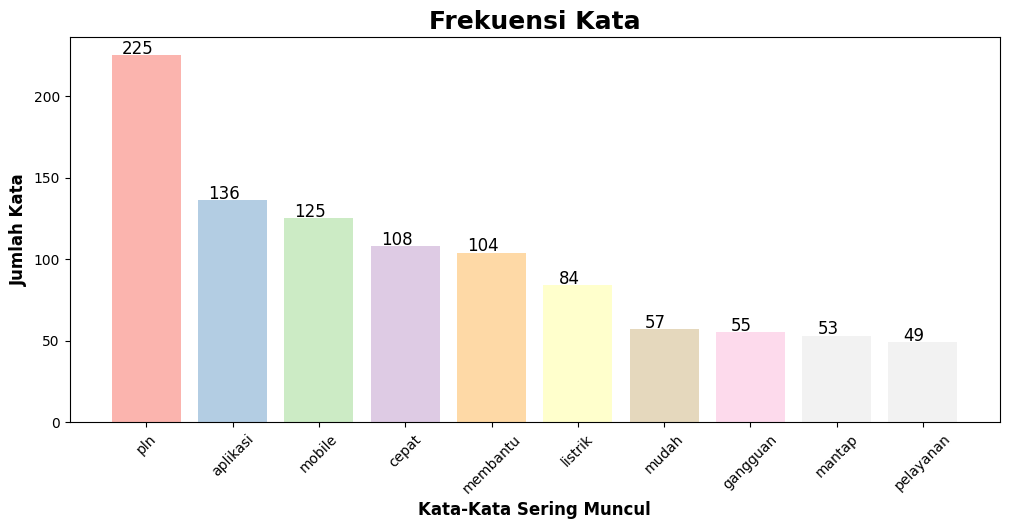

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

# Convert the list of words in 'stopword removal' to strings before joining
text = ' '.join([' '.join(words) for words in df_cleaned["stopword removal"]])

stopwords = set(STOPWORDS)

tokens = [word for word in text.split() if word not in stopwords]
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)
word, count = zip(*top_words)
# Menggunakan palet warna lebih lembut
colors = plt.cm.Pastel1(range(len(word)))

# Membuat plot
plt.figure(figsize=(12, 5))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')

# Menampilkan plot
plt.show()

# Labeling

## Pelabelan Data

In [ ]:
data = pd.DataFrame(data[['score',  'steming_data']])
data.head()

,score,steming_data
0,5,aplikasi bagustapi ganggu error jaya pln
1,5,aplikasi pln bantu beli token moga aplikasi pl...
2,5,terimakasih pln mobile terbaikkkk
3,5,layan oke cepat
4,5,pln mobile oke


In [ ]:
data['Sentiment'] = data ['score'].apply(lambda x: 'positive' if x > 3 else ('neutral' if x == 3 else 'negative'))
data

,score,steming_data,Sentiment
0,5,aplikasi bagustapi ganggu error jaya pln,positive
1,5,aplikasi pln bantu beli token moga aplikasi pl...,positive
2,5,terimakasih pln mobile terbaikkkk,positive
3,5,layan oke cepat,positive
4,5,pln mobile oke,positive
...,...,...,...
495,5,layan bagus,positive
496,5,pln mobile mudah beli pulsa listrik report gopay,positive
497,5,baik,positive
498,5,mantap,positive


## Wordcloud

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# memsisahkan dataset berdasarkan sentimen
sentimen_negative = data[data['Sentiment'] == 'negative']['steming_data'].str.cat(sep=' ')
sentimen_neutral = data[data['Sentiment'] == 'neutral']['steming_data'].str.cat(sep=' ')
sentimen_positive = data[data['Sentiment'] == 'positive']['steming_data'].str.cat(sep=' ')

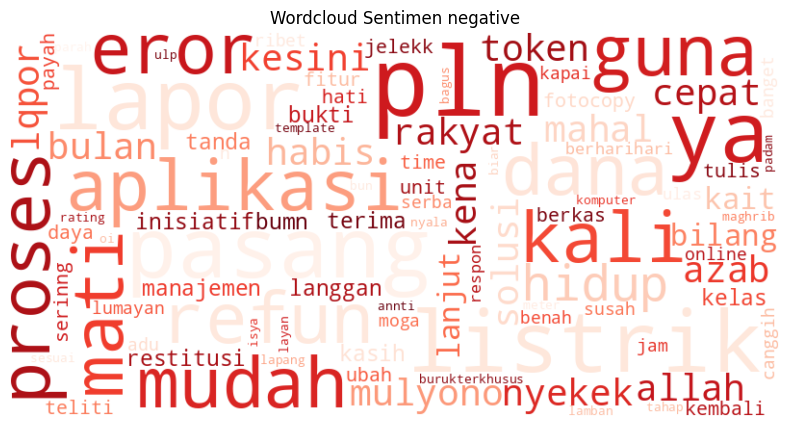

In [ ]:
# Membuat dan menampilkan wordcloud

def create_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, random_state=42, max_font_size=100, colormap='Reds',background_color='white').generate(text)
    return wordcloud

# membuat wordcloud untuk sentimen negatif
wordcloud_negative = create_wordcloud(sentimen_negative, 'Wordcloud Sentimen negative')

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud Sentimen negative')
plt.show()

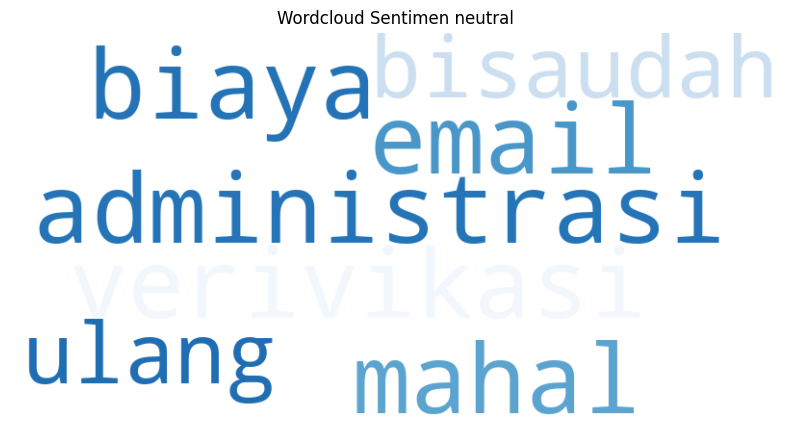

In [ ]:
# Membuat dan menampilkan wordcloud

def create_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, random_state=42, max_font_size=100, colormap='Blues',background_color='white').generate(text)
    return wordcloud

# membuat wordcloud untuk sentimen netral
wordcloud_neutral=create_wordcloud(sentimen_neutral, 'Wordcloud Sentimen netral')

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neutral, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud Sentimen neutral')
plt.show()

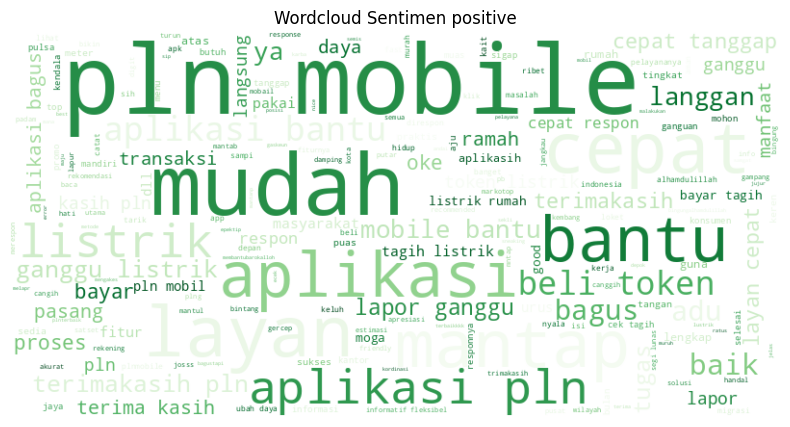

In [ ]:
# Membuat dan menampilkan wordcloud

def create_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, random_state=42, max_font_size=100, colormap='Greens',background_color='white').generate(text)
    return wordcloud

# membuat wordcloud untuk sentimen negatif
wordcloud_positive=create_wordcloud(sentimen_positive, 'Wordcloud Sentimen positive')

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud Sentimen positive')
plt.show()

## Distribusi Sentimen

In [ ]:
import plotly.express as px

# Hitung jumlah masing-masing label sentimen
sentiment_counts = data['Sentiment'].value_counts().reset_index()
sentiment_counts.columns = ['Sentiment', 'Count']

# Barplot dengan Plotly
fig = px.bar(
    sentiment_counts,
    x='Sentiment',
    y='Count',
    text='Count',
    title='Distribusi Sentimen menggunakan BERT',
    color='Sentiment',
    color_discrete_sequence=["#1dd1a1", "#ff6b6b", "#54a0ff"]
)

# Tambahkan label di atas bar
fig.update_traces(textposition='outside')
fig.update_layout(
    xaxis_title='Sentimen',
    yaxis_title='Jumlah',
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)

fig.show()


#Modeling

## Split Data

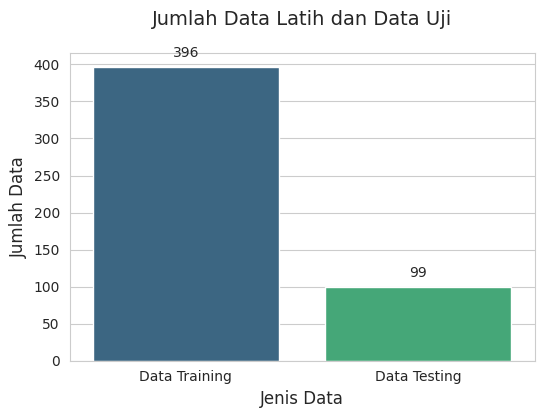

In [ ]:
# Memisahkan data training dan testing
from sklearn.model_selection import train_test_split

# Features (text data) and target (sentiment)
X = data['steming_data']
y = data['Sentiment']

# Split data into training and testing sets
# test_size: the proportion of the dataset to include in the test split (e.g., 0.2 for 20%)
# random_state: a seed for the random number generator for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Create labels and values for the bar plot
labels = ['Data Training', 'Data Testing']
values = [len(X_train), len(X_test)]

# Create the bar plot
plt.figure(figsize=(6, 4)) # Adjust figure size as needed
ax = sns.barplot(x=labels, y=values, palette='viridis')

# Add title and labels
plt.title('Jumlah Data Latih dan Data Uji', fontsize=14, pad=20)
plt.xlabel('Jenis Data', fontsize=12)
plt.ylabel('Jumlah Data', fontsize=12)

# Add the count values above the bars
for i, value in enumerate(values):
    ax.text(i, value + 10, str(value), ha='center', va='bottom', fontsize=10) # Adjust vertical position (+10) as needed

# Format y-axis to show integers
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x)}'))


plt.show()

##NLP

In [ ]:
!pip install transformers
!pip install bertopic

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

In [ ]:
X_train = X_train.tolist()

topic_model = BERTopic(
    language="indonesian",
    top_n_words=10,
    verbose=True
)
topics, probs = topic_model.fit_transform(X_train)
topic_model.get_topic_info()


2025-06-10 07:18:16,876 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

2025-06-10 07:18:44,486 - BERTopic - Embedding - Completed ✓
2025-06-10 07:18:44,490 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-06-10 07:19:07,212 - BERTopic - Dimensionality - Completed ✓
2025-06-10 07:19:07,217 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-06-10 07:19:07,243 - BERTopic - Cluster - Completed ✓
2025-06-10 07:19:07,251 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-06-10 07:19:07,314 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,7,-1_langgan_aplikasi_terimakasih_auto,"[langgan, aplikasi, terimakasih, auto, renovas...","[terimakasih pln aplikasi langgan apresiasi, r..."
1,0,92,0_listrik_token_beli_bayar,"[listrik, token, beli, bayar, mudah, ganggu, a...","[mudah lapor ganggu beli token listrik, aplika..."
2,1,69,1_mobile_pln_proses_mantap,"[mobile, pln, proses, mantap, aplikasi, adu, b...","[pln mobile bantu, pln mobile bantu, pln mobil..."
3,2,39,2_oke_mantap_josss_gercep,"[oke, mantap, josss, gercep, sampi, pln, baik,...","[oke pln, pln oke, pln oke]"
4,3,36,3_layan_cepat_ramah_tangan,"[layan, cepat, ramah, tangan, sigap, tingkat, ...","[layan cepat, layan cepat, layan layan cepat]"
5,4,35,4_terimakasih_kasih_bantu_tugas,"[terimakasih, kasih, bantu, tugas, responnya, ...","[bantu terimakasih, terimakasih bantu, terimak..."
6,5,30,5_cepat_tanggap_respon_ya,"[cepat, tanggap, respon, ya, kali, mantap, ata...","[cepat tanggap, cepat tanggap, cepat tanggap]"
7,6,27,6_bantu_aplikasi_masyarakat_lapor,"[bantu, aplikasi, masyarakat, lapor, langgan, ...","[aplikasi bantu, aplikasi bantu, aplikasi bantu]"
8,7,26,7_bagus_good_baik_cemerlang,"[bagus, good, baik, cemerlang, gaskeun, lord, ...","[bagus, bagus, pln bagus]"
9,8,23,8_aplikasi_bagus_ganggu_guna,"[aplikasi, bagus, ganggu, guna, langgan, digit...",[aplikasi bagus mudah langgan lapor ganggu bel...


In [ ]:
topic_model.visualize_barchart()

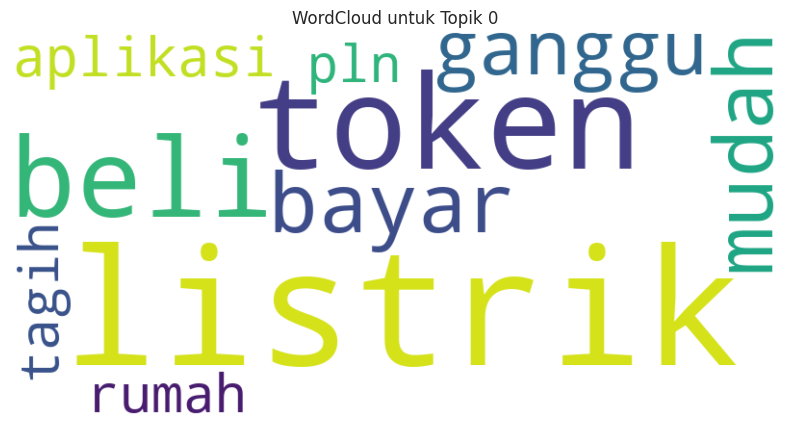

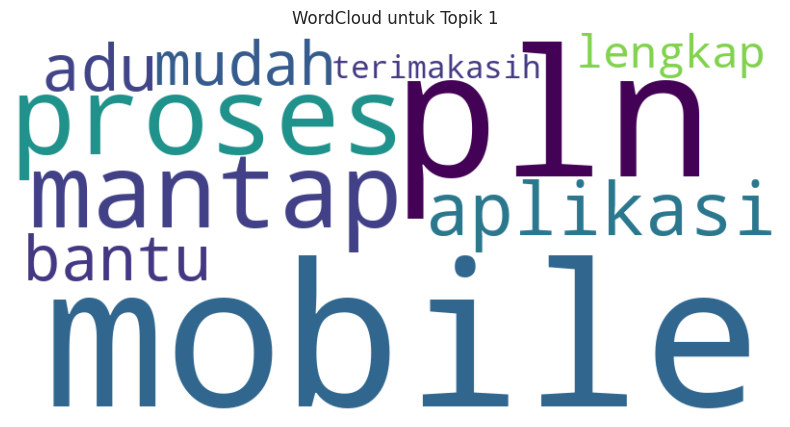

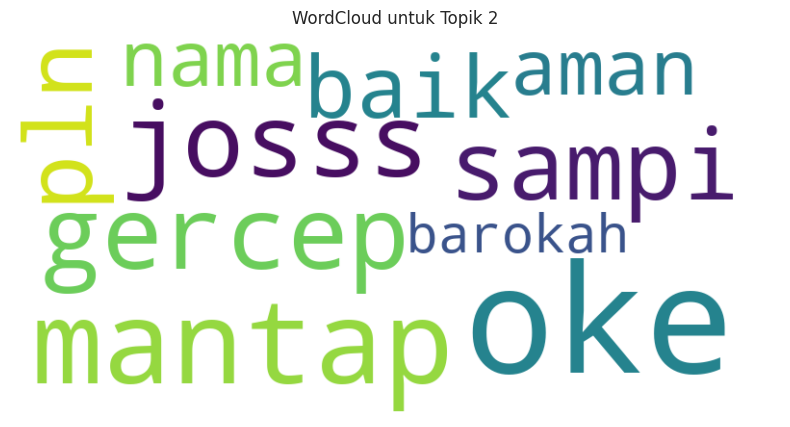

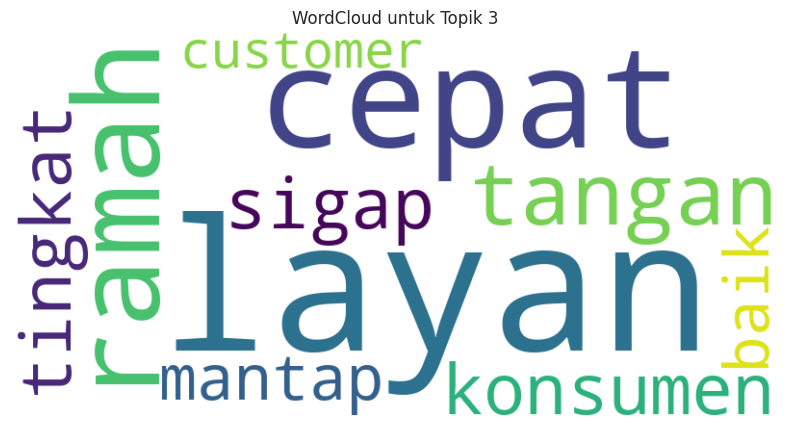

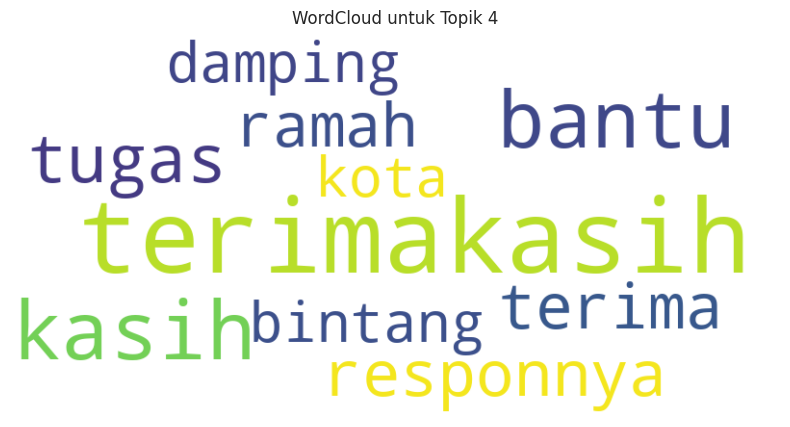

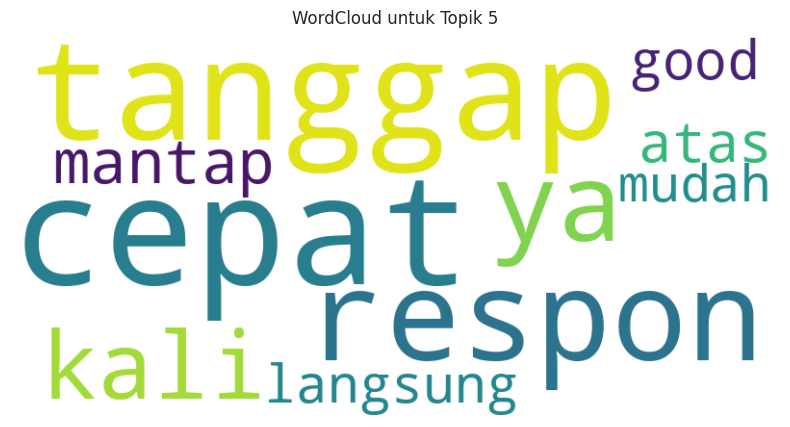

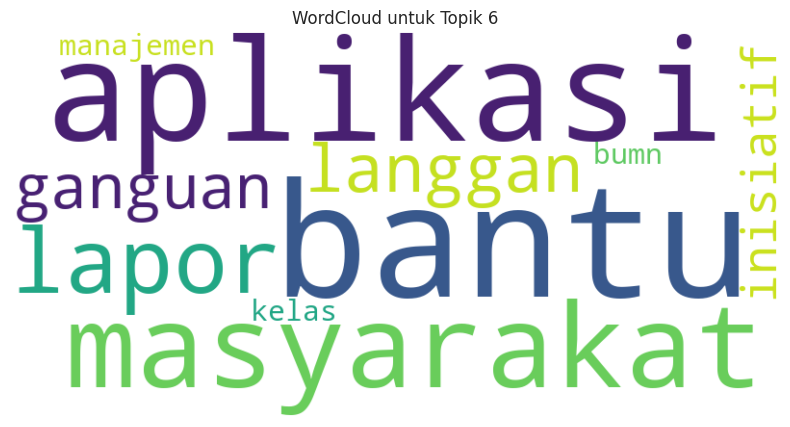

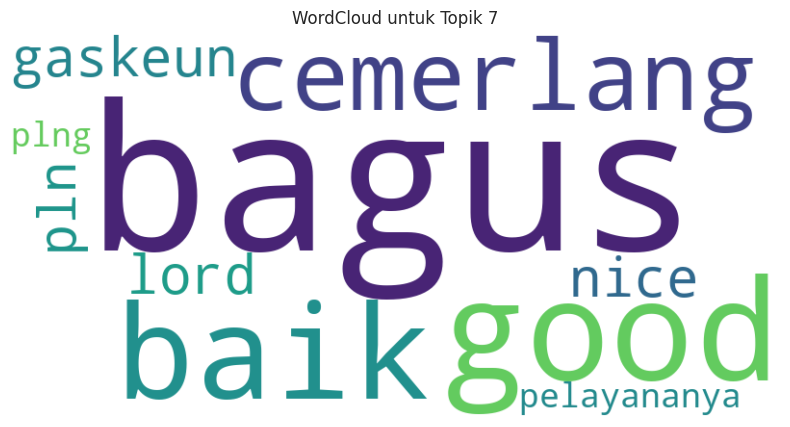

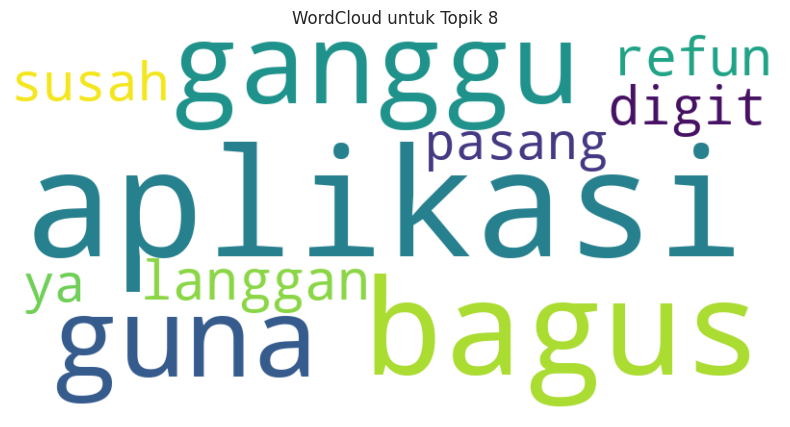

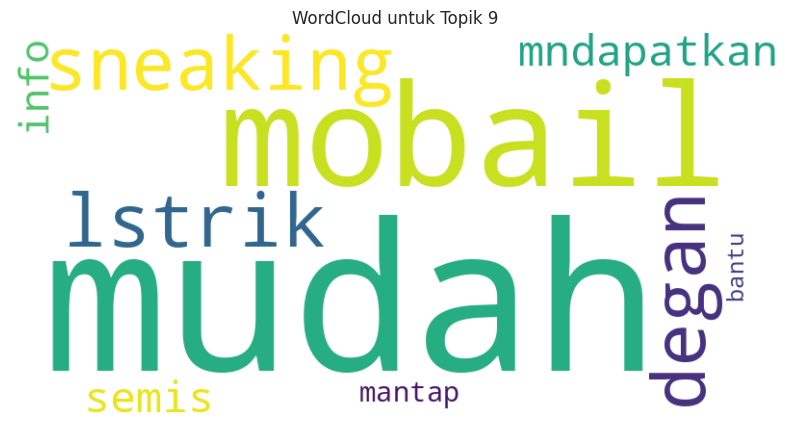

In [ ]:
# abaikan topik noise (-1) jika ada
topics = sorted([t for t in topic_model.get_topics().keys() if t != -1])

for topic in topics:
    # Mendapatkan kata-kata beserta bobotnya
    topic_words = dict(topic_model.get_topic(topic))

    # Membuat wordcloud berdasarkan frekuensi kata
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(topic_words)

    # Menampilkan wordcloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(f"WordCloud untuk Topik {topic}")
    plt.axis("off")
    plt.show()

In [ ]:
from transformers import pipeline
import pandas as pd

# 1. Buat pipeline
sentiment_classifier = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier"
)

# 2. Pastikan kolom data adalah List[str]
texts = data["steming_data"].dropna().astype(str).tolist()

# 3. Jalankan batch prediksi
results = sentiment_classifier(texts, truncation=True)

# 4. Buat DataFrame hasilnya
sentiment_df = pd.DataFrame(results)

# 5. Gabungkan dengan data asli
df_bert = pd.concat([data["steming_data"].copy().reset_index(drop=True), sentiment_df], axis=1)

# 6. Lihat hasil
df_bert[["steming_data", "label", "score"]].head()


Device set to use cpu
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


,steming_data,label,score
0,aplikasi bagustapi ganggu error jaya pln,negative,0.837730
1,aplikasi pln bantu beli token moga aplikasi pl...,positive,0.997203
2,terimakasih pln mobile terbaikkkk,positive,0.998673
3,layan oke cepat,positive,0.992281
4,pln mobile oke,neutral,0.810648


## Distribusi Sentimen

In [ ]:
import plotly.express as px

# Hitung jumlah masing-masing label sentimen
sentiment_counts = df_bert['label'].value_counts().reset_index()
sentiment_counts.columns = ['Sentiment', 'Count']

# Barplot dengan Plotly
fig = px.bar(
    sentiment_counts,
    x='Sentiment',
    y='Count',
    text='Count',
    title='Distribusi Sentimen menggunakan BERT',
    color='Sentiment',
    color_discrete_sequence=["#1dd1a1", "#ff6b6b", "#54a0ff"]
)

# Tambahkan label di atas bar
fig.update_traces(textposition='outside')
fig.update_layout(
    xaxis_title='Sentimen',
    yaxis_title='Jumlah',
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)

fig.show()


## evaluation model

In [ ]:
from sklearn.metrics import classification_report

# Pastikan hasil prediksi label dan label asli dalam format yang sama
y_true = data['Sentiment']
y_pred = df_bert['label']

# Tampilkan classification report
print(classification_report(y_true, y_pred, target_names=['negative', 'neutral', 'positive']))


              precision    recall  f1-score   support

    negative       0.21      0.64      0.32        14
     neutral       0.01      0.50      0.01         2
    positive       1.00      0.64      0.78       479

    accuracy                           0.64       495
   macro avg       0.41      0.60      0.37       495
weighted avg       0.97      0.64      0.77       495



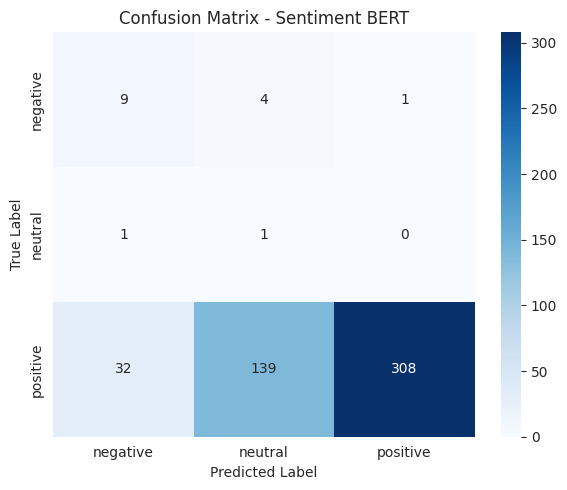

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns # pastikan Anda sudah mengimpor seaborn

cm = confusion_matrix(y_true, y_pred, labels=['negative', 'neutral', 'positive'])
# Perubahan di sini: 'NEGATIVE', 'NEUTRAL', 'POSITIVE' menjadi 'negative', 'neutral', 'positive'

# Buat visualisasi confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])

plt.title('Confusion Matrix - Sentiment BERT')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Conclusion

In [ ]:
# Gabungkan data asli dan hasil prediksi ke dalam satu DataFrame
hasil_klasifikasi = pd.DataFrame({
    'steming_data': data['steming_data'],
    'Sentiment': data['Sentiment'],
    'Predicted_Label': df_bert['label']
})

# Tampilkan 10 baris pertama
hasil_klasifikasi.head(10)

,steming_data,Sentiment,Predicted_Label
0,aplikasi bagustapi ganggu error jaya pln,positive,negative
1,aplikasi pln bantu beli token moga aplikasi pl...,positive,positive
2,terimakasih pln mobile terbaikkkk,positive,positive
3,layan oke cepat,positive,positive
4,pln mobile oke,positive,neutral
5,aplikasi bantu terima kasih pln,positive,neutral
6,layan cepat,positive,positive
7,layan cepat,positive,positive
8,mantap kerja respon ya cepat,positive,positive
9,aplikasi pln mobile bantu listrik,positive,neutral


<Figure size 800x600 with 0 Axes>

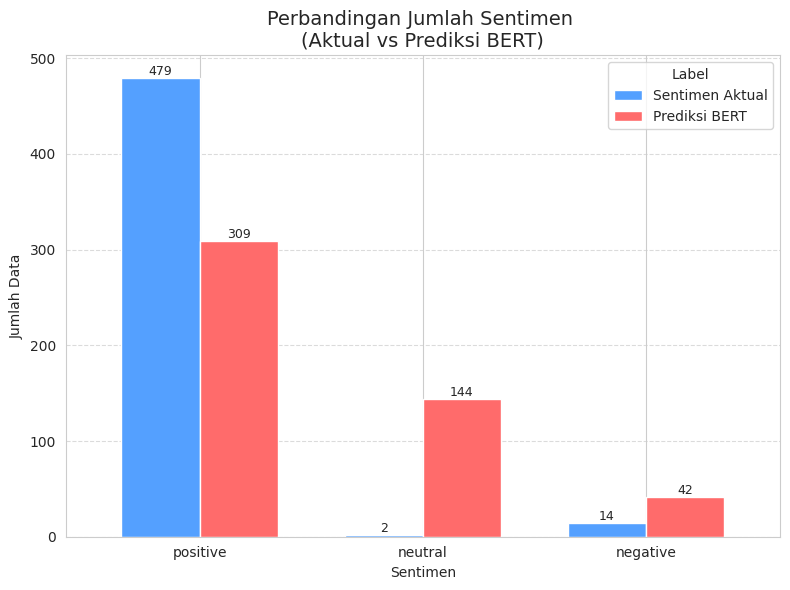

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Hitung jumlah kategori di label asli dan prediksi
sentimen_asli = hasil_klasifikasi['Sentiment'].value_counts().sort_index()
prediksi_bert = hasil_klasifikasi['Predicted_Label'].value_counts().sort_index()

# Gabungkan jadi satu DataFrame
perbandingan = pd.DataFrame({
    'Sentimen Aktual': sentimen_asli,
    'Prediksi BERT': prediksi_bert
}).reset_index().rename(columns={'index': 'Sentimen'}).sort_values(by='Sentimen', ascending=False)

# Plot barchart
plt.figure(figsize=(8, 6))
bar = perbandingan.set_index('Sentimen').plot(kind='bar', width=0.7, figsize=(8, 6), color=['#54a0ff', '#ff6b6b'])

plt.title('Perbandingan Jumlah Sentimen \n(Aktual vs Prediksi BERT)', fontsize=14)
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Label')

# Tambahkan label di atas bar
for p in bar.patches:
    bar.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

bert berdasarkan score kata, banyak kalimat yang mengarah ke negatif maupun netral tetapi rating tinggi